<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [2]:
!pip install -q torch torchvision

In [3]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.1 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [6]:
import io
import base64
import numpy as np
import torch
import torch.nn.functional as F
from scipy import ndimage
from transformers import AutoImageProcessor, AutoModel
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from sklearn.cluster import KMeans
from torchvision import transforms as T
import supervision as sv
from supervision.metrics import MeanAveragePrecision

from transformers import Sam3Processor, Sam3Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [11]:
IMAGE_PATH_target = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20220701_Waldegg/DJI_20220701173416_0008.JPG"
LABEL_PATH_target = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20220701173416_0008.txt"

IMAGE_PATH_reference = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20220701_Waldegg/DJI_20220701173639_0062.JPG"
LABEL_PATH_reference = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20220701173639_0062.txt"

RUMEX_CLASS_ID = 0

In [12]:
# YOLO box loader + load TARGET image & GT
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

target_image = Image.open(IMAGE_PATH_target).convert("RGB")
target_img_w, target_img_h = target_image.size
print(f"Target image size (W, H): {target_image.size}")

gt_boxes_target = load_yolo_boxes(LABEL_PATH_target, target_img_w, target_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_target)} GT box(es) on TARGET image with class id={RUMEX_CLASS_ID}.")

Target image size (W, H): (8192, 5460)
Loaded 2 GT box(es) on TARGET image with class id=0.


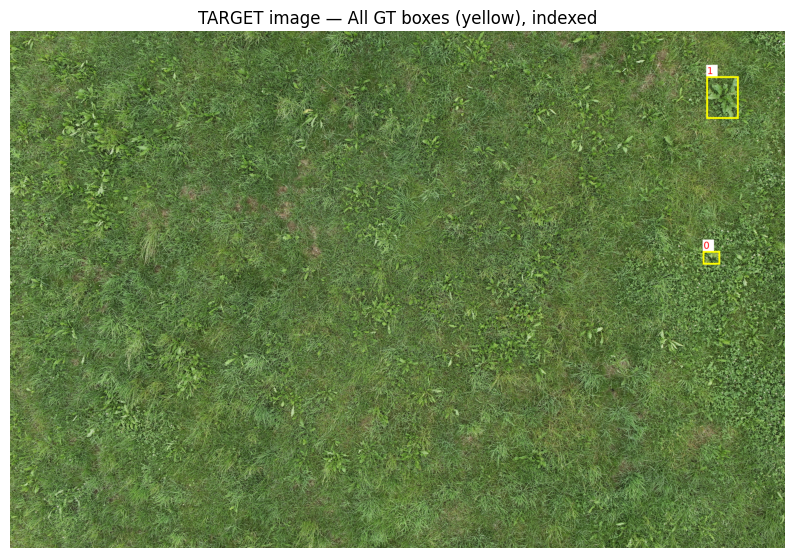

In [13]:
# Visualize TARGET image GT boxes (indexed)
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

def draw_indexed_boxes(base_image, boxes, color=(255, 255, 0)):
    preview = base_image.copy()
    draw = ImageDraw.Draw(preview)
    for i, (x0, y0, x1, y1) in enumerate(boxes):
        draw.rectangle([x0, y0, x1, y1], outline=color, width=20)
        text_x, text_y = int(x0), max(0, int(y0) - 120)
        draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
        draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)
    return preview

target_gt_preview = draw_indexed_boxes(target_image, gt_boxes_target)
plt.figure(figsize=(10, 8))
plt.imshow(target_gt_preview)
plt.title("TARGET image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

In [14]:
#  Load REFERENCE image + GT boxes
reference_image = Image.open(IMAGE_PATH_reference).convert("RGB")
ref_img_w, ref_img_h = reference_image.size
print(f"Reference image size (W, H): {reference_image.size}")

gt_boxes_reference = load_yolo_boxes(LABEL_PATH_reference, ref_img_w, ref_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_reference)} GT box(es) on REFERENCE image with class id={RUMEX_CLASS_ID}.")

Reference image size (W, H): (8192, 5460)
Loaded 1 GT box(es) on REFERENCE image with class id=0.


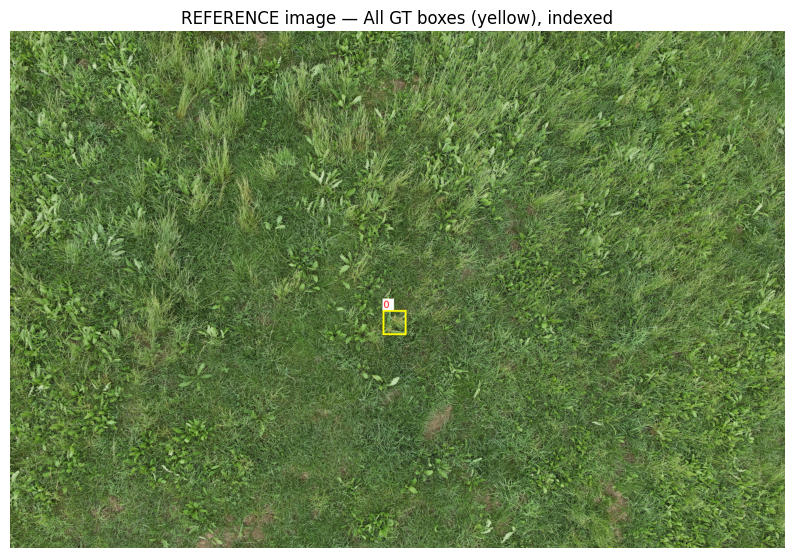

In [15]:
#  Visualize REFERENCE image GT boxes (indexed)
ref_gt_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
plt.figure(figsize=(10, 8))
plt.imshow(ref_gt_preview)
plt.title("REFERENCE image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

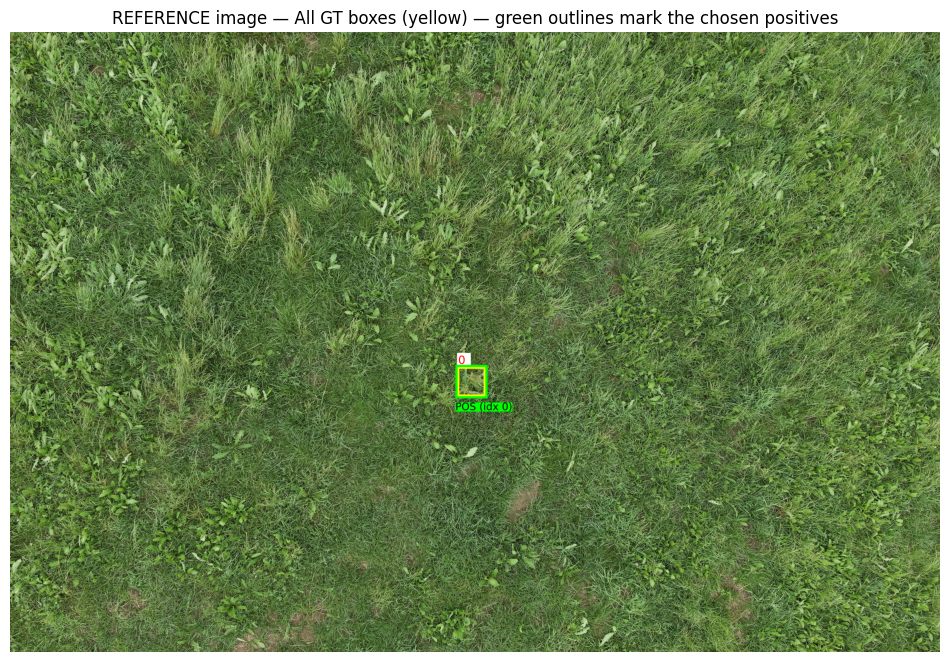

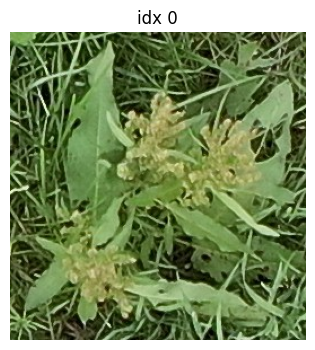

In [17]:
# Choose ONE positive exemplar by index (from REFERENCE image GT),
# crop it, and highlight against all reference GT boxes

positive_indices = [0]

exemplar_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
draw = ImageDraw.Draw(exemplar_preview)
HIGHLIGHT_PAD = 15
label_font = ImageFont.truetype(font_path, 90)

exemplar_crops = []
for positive_index in positive_indices:
    ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes_reference[positive_index]
    draw.rectangle(
        [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
        outline=(0, 255, 0), width=20,
    )
    label_text = f"POS (idx {positive_index})"
    label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
    text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
    draw.rectangle(text_bbox, fill=(0, 255, 0))
    draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

    PAD = 4
    crop = reference_image.crop((
        max(0, ex_x0 - PAD), max(0, ex_y0 - PAD),
        min(reference_image.width, ex_x1 + PAD), min(reference_image.height, ex_y1 + PAD),
    ))
    exemplar_crops.append(crop)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("REFERENCE image — All GT boxes (yellow) — green outlines mark the chosen positives")
plt.show()

fig, axes = plt.subplots(1, len(exemplar_crops), figsize=(4 * len(exemplar_crops), 4))
if len(exemplar_crops) == 1:
    axes = [axes]
for ax, crop, idx in zip(axes, exemplar_crops, positive_indices):
    ax.imshow(crop)
    ax.set_title(f"idx {idx}")
    ax.axis("off")
plt.show()

In [19]:
#DINOv2 model load
DINO_MODEL_NAME = "facebook/dinov2-base"   # swap to dinov2-large/-giant for more accuracy, more VRAM
dino_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_NAME)
dino_model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(DEVICE).eval()

DINO_PATCH_SIZE = dino_model.config.patch_size  # typically 14
print(f"Loaded {DINO_MODEL_NAME} on {DEVICE}, patch_size={DINO_PATCH_SIZE}")


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 301MB/s]


DINOv2 loaded.


In [20]:
# Patch feature extraction function
@torch.no_grad()
def extract_patch_features(pil_image, patch_size=DINO_PATCH_SIZE):
    """
    Runs one image (any size) through DINOv2 and returns a spatial grid of
    patch embeddings: shape (Hp, Wp, D), plus the (Hp, Wp) grid size.
    The image is internally resized to a multiple of patch_size by the processor.
    """
    inputs = dino_processor(images=pil_image, return_tensors="pt").to(DEVICE)
    _, _, H, W = inputs["pixel_values"].shape
    Hp, Wp = H // patch_size, W // patch_size

    outputs = dino_model(**inputs)
    tokens = outputs.last_hidden_state  # (1, 1 + num_register_tokens + Hp*Wp, D)

    num_prefix = tokens.shape[1] - Hp * Wp  # CLS (+ any register tokens)
    patch_tokens = tokens[0, num_prefix:, :]  # (Hp*Wp, D)
    patch_tokens = patch_tokens.reshape(Hp, Wp, -1)  # (Hp, Wp, D)

    return patch_tokens.float().cpu(), (Hp, Wp)

print("Feature extraction function ready.")

Feature extraction function ready.


In [21]:
# Tiled feature extraction (REFINEMENT #2 — the main fix)
def extract_tiled_features(pil_image, tile_size=896, overlap=0.25, patch_size=DINO_PATCH_SIZE):
    """
    Splits a large image into overlapping tiles, extracts patch features per tile,
    and stitches them into one full-resolution patch-grid feature map
    (overlapping regions are averaged). Returns (feat_map[Hp,Wp,D], (Hp,Wp)).
    """
    W, H = pil_image.size
    stride = int(tile_size * (1 - overlap))

    xs = list(range(0, max(W - tile_size, 0) + 1, stride)) or [0]
    ys = list(range(0, max(H - tile_size, 0) + 1, stride)) or [0]
    if xs[-1] + tile_size < W:
        xs.append(W - tile_size)
    if ys[-1] + tile_size < H:
        ys.append(H - tile_size)

    Hp_full, Wp_full = H // patch_size, W // patch_size
    feat_dim = None
    accum = None
    counts = None

    for y0 in ys:
        for x0 in xs:
            x1, y1 = min(x0 + tile_size, W), min(y0 + tile_size, H)
            tile = pil_image.crop((x0, y0, x1, y1))
            tile_feats, (hp, wp) = extract_patch_features(tile, patch_size)
            if feat_dim is None:
                feat_dim = tile_feats.shape[-1]
                accum = torch.zeros(Hp_full, Wp_full, feat_dim)
                counts = torch.zeros(Hp_full, Wp_full, 1)

            py0, px0 = y0 // patch_size, x0 // patch_size
            py1, px1 = min(py0 + hp, Hp_full), min(px0 + wp, Wp_full)
            accum[py0:py1, px0:px1, :] += tile_feats[: py1 - py0, : px1 - px0, :]
            counts[py0:py1, px0:px1, :] += 1

    counts = counts.clamp(min=1)
    feat_map = accum / counts
    return feat_map, (Hp_full, Wp_full)
print("Tiled feature extraction function ready.")

Tiled feature extraction function ready.


In [22]:
# Multi-scale feature extraction
def extract_multiscale_features(pil_image, scales=(1.0, 0.5), tile_size=896, overlap=0.25):
    """
    Runs tiled feature extraction at several scales, upsamples every scale's
    feature map to the resolution of the largest scale, then averages them.
    Returns (feat_map[Hp,Wp,D] normalized, (Hp,Wp), pixels-per-patch at scale 1.0).
    """
    W, H = pil_image.size
    base_feats = None
    target_hw = None
    combined = None

    for s in sorted(scales, reverse=True):
        scaled_img = pil_image.resize((max(1, int(W * s)), max(1, int(H * s))), Image.BICUBIC)
        feats, (hp, wp) = extract_tiled_features(scaled_img, tile_size=tile_size, overlap=overlap)

        if target_hw is None:
            target_hw = (hp, wp)
            base_feats = feats
            combined = feats.clone()
            continue

        feats_t = feats.permute(2, 0, 1).unsqueeze(0)  # (1,D,hp,wp)
        feats_up = F.interpolate(feats_t, size=target_hw, mode="bilinear", align_corners=False)
        combined += feats_up.squeeze(0).permute(1, 2, 0)

    combined = combined / len(scales)
    combined = F.normalize(combined, dim=-1)  # L2-normalize per spatial location
    patch_px = W / target_hw[1]  # pixels-per-patch column (approx, at scale 1.0)
    return combined, target_hw, patch_px

Total exemplar patches (all exemplars x rotations): torch.Size([1368, 768])
Total target patches (tiled): torch.Size([315392, 768])


Max similarity per target patch — percentiles:
     50th pct: 0.655
     90th pct: 0.752
     95th pct: 0.770
     99th pct: 0.797
   99.5th pct: 0.807
   99.9th pct: 0.826
  max        : 0.892


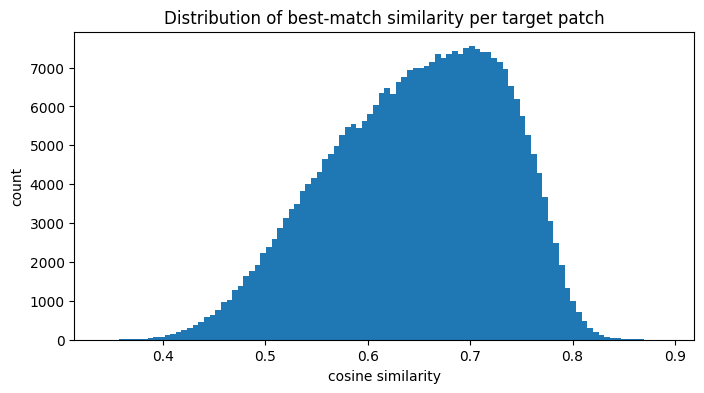

In [23]:
# build exemplar embedding(s) from the reference crop(s)
def build_exemplar_prototypes(exemplar_crops, n_prototypes_per_crop=3):
    """
    For each exemplar crop: extract multi-scale patch features, then cluster the
    patch tokens with KMeans to get a few representative prototype vectors
    (handles exemplars that contain both object and background/edge patches).
    Returns a single (N_prototypes, D) L2-normalized tensor.
    """
    all_prototypes = []
    for crop in exemplar_crops:
        feats, (hp, wp), _ = extract_multiscale_features(crop, scales=(1.0, 0.5))
        flat = feats.reshape(-1, feats.shape[-1]).numpy()

        k = min(n_prototypes_per_crop, flat.shape[0])
        if k <= 1:
            proto = flat.mean(axis=0, keepdims=True)
        else:
            km = KMeans(n_clusters=k, n_init=4, random_state=0).fit(flat)
            proto = km.cluster_centers_

        all_prototypes.append(torch.tensor(proto, dtype=torch.float32))

    prototypes = torch.cat(all_prototypes, dim=0)
    prototypes = F.normalize(prototypes, dim=-1)
    return prototypes

exemplar_prototypes = build_exemplar_prototypes(exemplar_crops, n_prototypes_per_crop=3)
print("Exemplar prototype bank:", exemplar_prototypes.shape)

Total negative/background patches: torch.Size([800, 768])
Margin score (pos similarity − neg similarity) percentiles:
     50th pct: 0.057
     90th pct: 0.162
     95th pct: 0.195
     99th pct: 0.262
   99.5th pct: 0.289
   99.9th pct: 0.350
  max        : 0.467


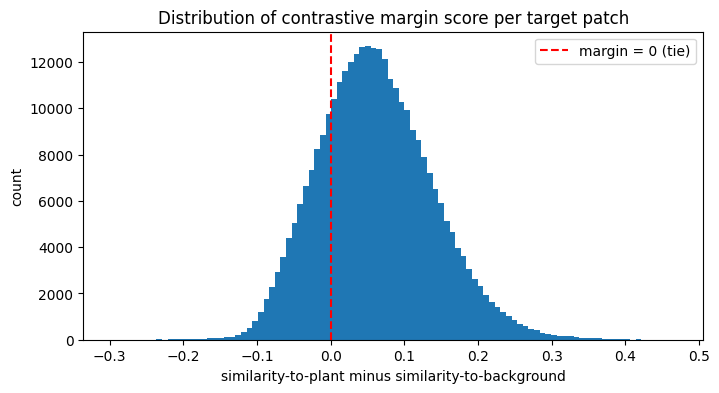

In [24]:
# Extract TARGET image features + similarity heatmap
target_feats, (target_hp, target_wp), patch_px = extract_multiscale_features(
    target_image, scales=(1.0, 0.5)
)

flat_target = target_feats.reshape(-1, target_feats.shape[-1])          # (Hp*Wp, D)
sims = flat_target @ exemplar_prototypes.T                              # cosine sim (already L2-normed)
heatmap = sims.max(dim=1).values.reshape(target_hp, target_wp).numpy()  # best matching prototype per patch

heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

plt.figure(figsize=(10, 8))
plt.imshow(target_image, alpha=0.6)
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, extent=(0, target_img_w, target_img_h, 0))
plt.title("TARGET image — exemplar similarity heatmap")
plt.axis("off")
plt.colorbar(fraction=0.03)
plt.show()

In [25]:
# Threshold + connected-component clustering → candidate boxes
SIM_THRESHOLD = 0.6      # tune based on heatmap_norm above
MIN_COMPONENT_PATCHES = 2

binary_mask = heatmap_norm >= SIM_THRESHOLD
labeled, n_components = ndimage.label(binary_mask, structure=np.ones((3, 3)))

candidate_boxes, candidate_scores = [], []
for comp_id in range(1, n_components + 1):
    ys, xs = np.where(labeled == comp_id)
    if len(xs) < MIN_COMPONENT_PATCHES:
        continue
    x0p, x1p = xs.min(), xs.max() + 1
    y0p, y1p = ys.min(), ys.max() + 1

    x0, x1 = x0p * patch_px, x1p * patch_px
    y0, y1 = y0p * patch_px, y1p * patch_px
    score = heatmap_norm[ys, xs].max()

    candidate_boxes.append([x0, y0, x1, y1])
    candidate_scores.append(float(score))

candidate_boxes = np.array(candidate_boxes, dtype=np.float32)
candidate_scores = np.array(candidate_scores, dtype=np.float32)
print(f"Found {len(candidate_boxes)} candidate cluster(s) before NMS.")

# simple NMS on candidate boxes
import torchvision
keep = torchvision.ops.nms(torch.tensor(candidate_boxes), torch.tensor(candidate_scores), iou_threshold=0.3)
candidate_boxes = candidate_boxes[keep.numpy()]
candidate_scores = candidate_scores[keep.numpy()]
print(f"{len(candidate_boxes)} candidate(s) after NMS.")

preview = draw_indexed_boxes(target_image, candidate_boxes, color=(0, 255, 0))
plt.figure(figsize=(10, 8))
plt.imshow(preview)
plt.title("TARGET image — candidate boxes from clustering (pre-SAM3)")
plt.axis("off")
plt.show()

Margin threshold (top 1.0% of patches): 0.262
3154 target patch(es) clear the margin threshold (before reverse-NN check).
Found 73 confirmed matching points in the TARGET image (margin + reverse-NN).


In [26]:
#  Load SAM3 (via transformers) and refine each candidate box into a mask
#  PVS (promptable visual segmentation) which is the SAM2-style API that takes a single box (or point)
#  and refines it into one precise mask. That's the box-refinement role of our candidate boxes need.
!pip install -q -U "git+https://github.com/huggingface/transformers"

from transformers import Sam3TrackerModel, Sam3TrackerProcessor

SAM3_CHECKPOINT = "facebook/sam3"  # gated checkpoint — request access on the HF model page first

sam3_tracker_model = Sam3TrackerModel.from_pretrained(SAM3_CHECKPOINT).to(DEVICE).eval()
sam3_tracker_processor = Sam3TrackerProcessor.from_pretrained(SAM3_CHECKPOINT)

final_masks, final_boxes, final_scores = [], [], []

for box, cscore in zip(candidate_boxes, candidate_scores):
    # input_boxes: (image_batch, num_boxes_per_image, 4) in absolute xyxy pixel coords
    input_boxes = [[[float(box[0]), float(box[1]), float(box[2]), float(box[3])]]]

    inputs = sam3_tracker_processor(
        images=target_image, input_boxes=input_boxes, return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = sam3_tracker_model(**inputs)

    masks = sam3_tracker_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu(),
    )[0]  # shape: (num_boxes, num_preds_per_box, H, W)

    iou_scores = outputs.iou_scores[0, 0]           # (num_preds_per_box,)
    best = int(torch.argmax(iou_scores))
    best_mask = masks[0, best].numpy().astype(bool)  # (H, W) boolean mask at original resolution

    final_masks.append(best_mask)
    final_boxes.append(box)          # keep our own detection box for metrics/plotting
    final_scores.append(float(cscore))

print(f"SAM3 (transformers) produced {len(final_masks)} final mask(s).")

Adaptive threshold (top 1.0% of scores): 0.797
Found 201 confirmed matching points in the TARGET image.


Proposed 150 candidate object box(es) (x1,y1,x2,y2):
   [6155.0, 3097.0, 6175.0, 3117.0]
   [7853.0, 207.0, 7873.0, 227.0]
   [557.0, 891.0, 577.0, 911.0]
   [7965.0, 1827.0, 7985.0, 1847.0]
   [7475.0, 1841.0, 7495.0, 1861.0]
   [7307.0, 3169.0, 7369.0, 3215.0]
   [291.0, 1547.0, 353.0, 1595.0]
   [7105.0, 1981.0, 7125.0, 2001.0]
   [7699.0, 1701.0, 7719.0, 1721.0]
   [5207.0, 207.0, 5227.0, 227.0]
   [7867.0, 1785.0, 7915.0, 1805.0]
   [7363.0, 2595.0, 7383.0, 2615.0]
   [6267.0, 319.0, 6287.0, 339.0]
   [5681.0, 2469.0, 5701.0, 2489.0]
   [6715.0, 207.0, 6735.0, 241.0]
   [683.0, 1757.0, 703.0, 1777.0]
   [5373.0, 2595.0, 5407.0, 2657.0]
   [6239.0, 235.0, 6259.0, 255.0]
   [7489.0, 2609.0, 7509.0, 2629.0]
   [7559.0, 571.0, 7607.0, 605.0]
   [5165.0, 3251.0, 5185.0, 3271.0]
   [1605.0, 3837.0, 1625.0, 3857.0]
   [7321.0, 403.0, 7341.0, 423.0]
   [6309.0, 39.0, 6343.0, 87.0]
   [767.0, 3475.0, 787.0, 3495.0]
   [7651.0, 487.0, 7699.0, 591.0]
   [8077.0, 1785.0, 8097.0, 1805.0]
   [7

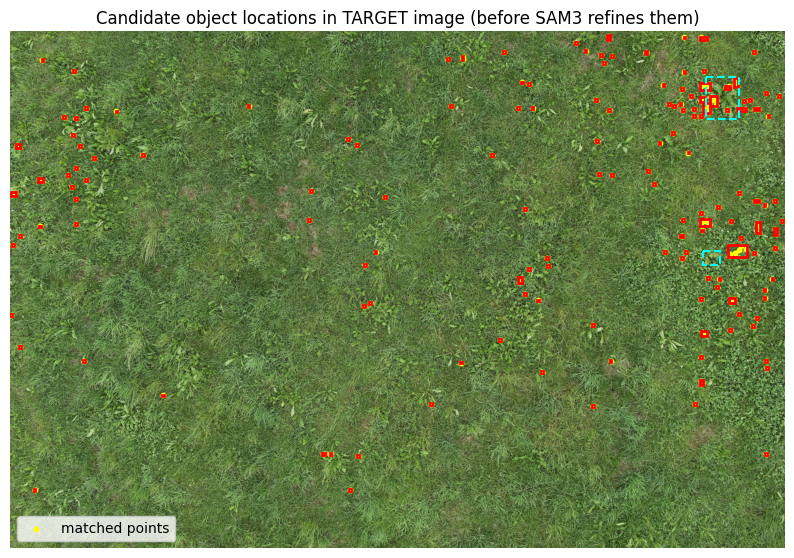

In [27]:
# ============================================================
# CELL 16 — Display final detections (lime) vs TARGET image GT boxes (yellow)
# ============================================================
final_preview = target_image.copy()
draw = ImageDraw.Draw(final_preview, "RGBA")

for mask in final_masks:
    mask_np = np.asarray(mask).astype(bool)
    overlay = Image.new("RGBA", final_preview.size, (0, 0, 0, 0))
    overlay_np = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
    overlay_np[mask_np] = (50, 255, 50, 100)  # lime, semi-transparent
    overlay = Image.fromarray(overlay_np, "RGBA")
    final_preview.paste(overlay, (0, 0), overlay)

draw = ImageDraw.Draw(final_preview)
for x0, y0, x1, y1 in final_boxes:
    draw.rectangle([x0, y0, x1, y1], outline=(50, 255, 50), width=15)
for x0, y0, x1, y1 in gt_boxes_target:
    draw.rectangle([x0, y0, x1, y1], outline=(255, 255, 0), width=15)

plt.figure(figsize=(12, 10))
plt.imshow(final_preview)
plt.title("Final detections (lime) vs GT (yellow)")
plt.axis("off")
plt.show()

In [28]:
# ============================================================
# CELL 17 — Compute detection metrics (box-based) against TARGET image GT
# ============================================================
!pip install -q supervision

import numpy as np
import supervision as sv
from supervision.metrics import MeanAveragePrecision

pred_boxes_np = np.array(final_boxes, dtype=np.float32) if final_boxes else np.zeros((0, 4), dtype=np.float32)
pred_scores_np = np.array(final_scores, dtype=np.float32) if final_scores else np.zeros((0,), dtype=np.float32)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
)
gt_detections = sv.Detections(
    xyxy=gt_boxes_target,
    class_id=np.zeros(len(gt_boxes_target), dtype=int),
)

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes_target)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes_target)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Hugging Face SAM3 model + processor loaded.
